In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Scikit-learn ofrece una variedad de modelos Naive Bayes. Para este problema, utilizamos MultinomialNB, que es adecuado para datos de conteo como este.
from sklearn.naive_bayes import MultinomialNB   

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# TP3: Detector de SPAM

Uno de los problemas más comunes en clasificación es la detección de correos electrónicos SPAM. Uno de los primeros modelos utilizados para abordar este problema fue el clasificador de Bayes ingenuo (Naive Bayes). La detección de SPAM sigue siendo un problema persistente en el mundo digital, ya que los spammers continúan adaptando sus estrategias para evadir los filtros de correo no deseado.

Además del clasificador de Bayes ingenuo, se han desarrollado y utilizado técnicas más avanzadas, como algoritmos de aprendizaje automático, redes neuronales y métodos basados en reglas.

En este trabajo práctico utilizaremos un conjunto de datos que contiene 4601 observaciones de correos electrónicos, de los cuales 2788 son legítimos y 1813 son SPAM. Como el contenido de los correos electrónicos es un tipo de dato no estructurado, es necesario procesarlo. En este caso, el dataset ya ha sido preprocesado utilizando técnicas típicas de Procesamiento de Lenguaje Natural (NLP), como el conteo de la frecuencia de palabras observadas en los correos.

El procesamiento de lenguaje natural desempeña un rol fundamental en la detección de SPAM, ya que permite analizar el contenido textual y extraer características relevantes para la clasificación. Además del simple conteo de palabras, se pueden aplicar técnicas más sofisticadas, como la extracción de características semánticas o el análisis de sentimientos, para mejorar la precisión de los modelos.

En este dataset, se cuenta la cantidad de ocurrencias de cada palabra en los distintos correos:

![spam counter](./spam.png)

Para preservar la privacidad de los mensajes, las frecuencias han sido normalizadas. El dataset está compuesto por 54 columnas de atributos denominadas:

- `word_freq_XXXX`: donde `XXXX` representa una palabra o símbolo. Los valores son enteros que van de 0 a 20.000.

Adicionalmente, hay una columna llamada `spam`, que toma el valor 1 si el correo es SPAM, y 0 si es legítimo.

Los clasificadores de Bayes ingenuos fueron de los primeros filtros utilizados por aplicaciones de correo electrónico, y se basan en este principio: partiendo de una probabilidad a priori de que un correo sea SPAM, ciertas palabras pueden modificar esa probabilidad a posteriori, indicando con mayor o menor certeza si un mensaje es o no SPAM.

### Carga del dataset

In [39]:
dataset = pd.read_csv("dataset/spambase.csv") # Cargamos los datos desde un archivo CSV
dataset.head(10)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
0,0,640,640,0,320,0,0,0,0,0,...,0,0,0,0,0,0,778,0,0,1
1,210,280,500,0,140,280,210,70,0,940,...,0,0,0,0,132,0,372,180,48,1
2,60,0,710,0,1230,190,190,120,640,250,...,60,0,0,10,143,0,276,184,10,1
3,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,137,0,137,0,0,1
4,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,135,0,135,0,0,1
5,0,0,0,0,1850,0,0,1850,0,0,...,0,0,0,0,223,0,0,0,0,1
6,0,0,0,0,1920,0,0,0,0,640,...,0,0,0,0,54,0,164,54,0,1
7,0,0,0,0,1880,0,0,1880,0,0,...,0,0,0,0,206,0,0,0,0,1
8,150,0,460,0,610,0,300,0,920,760,...,0,0,0,0,271,0,181,203,22,1
9,60,120,770,0,190,320,380,0,60,0,...,0,0,0,40,30,0,244,81,0,1


Para obtener las palabras más frecuentes según si el correo es SPAM o no, podemos agrupar por clase con `groupby`::

In [40]:
column_sum = dataset.groupby(by="spam", as_index=False).sum()
column_sum

,spam,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#
0,0,204860,681569,559220,2470,504739,124190,26160,107100,106080,...,1159138,800669,22840,142820,140182,442116,63242,306634,32475,60536
1,1,276190,298510,732080,298550,931799,317050,499309,377360,308320,...,226790,26700,2210,3810,37299,197563,14864,931352,316328,143003


Luego, se pueden combinar las columnas usando [pd.melt](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) para facilitar la visualización.


In [41]:
melted = pd.melt(column_sum, id_vars="spam", var_name="word", value_name="frecuency")
melted.head(10)

,spam,word,frecuency
0,0,word_freq_make,204860
1,1,word_freq_make,276190
2,0,word_freq_address,681569
3,1,word_freq_address,298510
4,0,word_freq_all,559220
5,1,word_freq_all,732080
6,0,word_freq_3d,2470
7,1,word_freq_3d,298550
8,0,word_freq_our,504739
9,1,word_freq_our,931799


Palabras más frecuentes en correos SPAM y NO SPAM

In [49]:
top10 = (melted.sort_values(["spam", "frecuency"], ascending=[True, False])
            .groupby("spam", group_keys=False)
            .head(10)
        ).reset_index(drop=True)
top10

,spam,word,frecuency
0,0,word_freq_you,3541702
1,0,word_freq_george,3527559
2,0,word_freq_hp,2496576
3,0,word_freq_will,1495268
4,0,word_freq_your,1223098
5,0,word_freq_hpl,1204398
6,0,word_freq_re,1159138
7,0,word_freq_edu,800669
8,0,word_freq_address,681569
9,0,word_freq_meeting,604460


1. ¿Cuáles son las 10 palabras o símbolos más frecuentes en correos SPAM y en correos NO SPAM?<br>

    1.1 ¿Hay palabras o símbolos en común?<br>

    * Dentro de las palabras en común está You, Will y Your.<br>

    1.2 ¿Alguna resulta llamativa?<br>
    
    * Dentro de las NO SPAM, resulta llamativo el uso de George. Dentro de las SPAM era esperable free, business y !.


### Preparación de los datos

Obtenemos los atributos y el target:

In [50]:
X = dataset.drop(columns="spam")
y = dataset["spam"]

### División del dataset en entrenamiento y evaluación

2. Separe el conjunto de datos en un conjunto de entrenamiento (70%) y uno de prueba (30%).

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.3, random_state=42)

3. Utilizando un clasificador de Bayes ingenuo, entrene el modelo con el conjunto de entrenamiento.

In [57]:
model_multinomial = MultinomialNB()
model_multinomial.fit(X_train, y_train)

MultinomialNB()

### Escalado para regresión logística

Aplicamos un escalado Min-Max para hacer uno diferente al tipico StandardScaler():

In [58]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos los arrays escalados a DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

4. Utilizando un clasificador de Regresión Logística, entrene el modelo con el conjunto de entrenamiento (en este caso, normalice los datos).

In [60]:
model_regression = LogisticRegression()
model_regression.fit(X_train_scaled, y_train)

LogisticRegression()

# Evaluación de los modelos

In [62]:
# Predicciones del clasificador de Bayes ingenuo
y_multinomial_pred = model_multinomial.predict(X_test)

# Predicciones del clasificador de Regresión Logística
y_regression_pred = model_regression.predict(X_test_scaled)

### Matriz de confusión

In [73]:
cm_multinomial = confusion_matrix(y_test, y_multinomial_pred)

cm_regression = confusion_matrix(y_test, y_regression_pred)

cms = [cm_multinomial, cm_regression]
titles = ["Bayes Ingenuo", "Regresión Logistica"]

5. Calcule la matriz de confusión en el conjunto de prueba para ambos modelos.

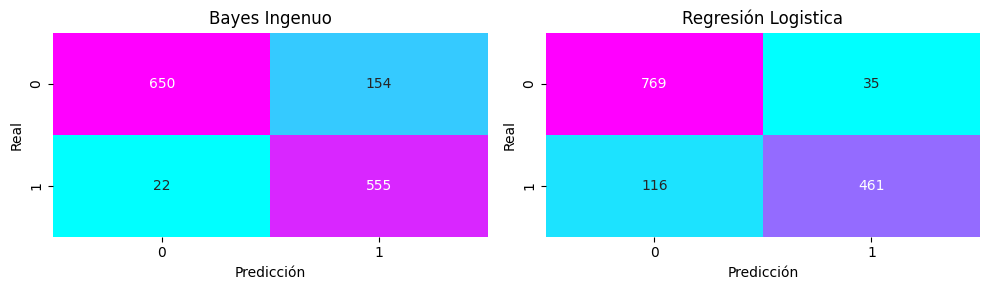

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

  - ¿Qué tipo de error comete más cada modelo?
    * Bayes Ingenuo comete más errores de tipo I, con 154 FP.
    * Regresión Logística comete más errores de tipo II, obtuvo 116 FN.
  - ¿Cuál de los dos tipos de error considera más importante en este problema?
    * Consideramos más importante el error tipo I, un alto número de FP indica que el detector de SPAM está filtrando correos que no son SPAM.

6. Calcule las métricas de precisión (precision) y recuperación (recall) para ambos modelos.

In [77]:
print(titles[0])
print(f"Precision: {precision_score(y_test, y_multinomial_pred)}")
print(f"Recuperación: {recall_score(y_test, y_multinomial_pred)}\n")

print(titles[1])
print(f"Precision: {precision_score(y_test, y_regression_pred)}")
print(f"Recuperación: {recall_score(y_test, y_regression_pred)}")

Bayes Ingenuo
Precision: 0.7827926657263752
Recuperación: 0.9618717504332756

Regresión Logistica
Precision: 0.9294354838709677
Recuperación: 0.7989601386481803


- ¿Cuál es el mejor modelo según cada métrica?
    * Según la métrica de precisión, el mejor modelo es Regresión Logística con un valor de 0.92, mientras que Bayes Ingenuo obtuvo 0.78.
    * Según la métrica de recuperación, el mejor modelo es Bayes Ingenuo con un valor de 0.96, mientras que Regresión Logística obtuvo 0.79.
- ¿Cómo se relacionan estas métricas con los errores analizados en el punto anterior? Fundamente su respuesta.
    * La precisión se relaciona con el error tipo I (FP), ya que es la proporción de los clasificados positivos (TP) sobre el total de clasificados como positivos (TP + FP):

  $$ Precision = \frac{TP}{TP + FP}$$
    Como podemos observar, si FP aumenta, la precisión disminuye. Lo que nos lleva a deducir que se obtiene una "Alta Precisión" cuando se logra pocos falsos positivos (menos correos NO SPAM filtrados por error).

    * El recall se relaciona con el error tipo 2 (FN), ya que mide que proporción de los correos realmente SPAM fueron  detectados:
    $$Recall = \frac{TP}{TP + FN} $$
    En este caso, si FN aumenta, recall disminuye. Esto sería equivalente a decir que un "Alto Recall" se obtiene cuando se logran pocos falsos negativos (la mayoría del SPAM es detectado)

    En el punto anterior dijimos que el error tipo I es más crítico en nuestro caso del detector de SPAM, y por lo tanto la `precisión` es más importante, ya que queremos estar seguros de que cuando el molelo clasifique correos como SPAM
    sean en realidad SPAM y no filtrar correos importantes. Todo esto sobre la posibilidad de que el modelo permita dejar pasar algunos  SPAM o errores del tipo II (FN).

In [82]:
from sklearn.metrics import classification_report
target_names = ["No SPAM", "SPAM"]

print(titles[0])
print(classification_report(y_test, y_multinomial_pred, target_names=target_names))

print(titles[1])
print(classification_report(y_test, y_regression_pred, target_names=target_names))

Bayes Ingenuo
              precision    recall  f1-score   support

     No SPAM       0.97      0.81      0.88       804
        SPAM       0.78      0.96      0.86       577

    accuracy                           0.87      1381
   macro avg       0.88      0.89      0.87      1381
weighted avg       0.89      0.87      0.87      1381

Regresión Logistica
              precision    recall  f1-score   support

     No SPAM       0.87      0.96      0.91       804
        SPAM       0.93      0.80      0.86       577

    accuracy                           0.89      1381
   macro avg       0.90      0.88      0.88      1381
weighted avg       0.89      0.89      0.89      1381



7. Obtenga la curva ROC y el AUC (Área Bajo la Curva ROC) de ambos modelos.

In [88]:
from sklearn.metrics import roc_curve

y_multinomial_proba = model_multinomial.predict_proba(X_test)
y_regression_proba = model_regression.predict_proba(X_test_scaled)

In [89]:

fpr_y_multinomial, tpr_y_multinomial, thr_y_multinomial = roc_curve(y_test, y_multinomial_proba[:, 1])
fpr_y_regression, tpr_y_regression, thr_y_regression = roc_curve(y_test, y_regression_proba[:, 1])

Graficamos la curva ROC:

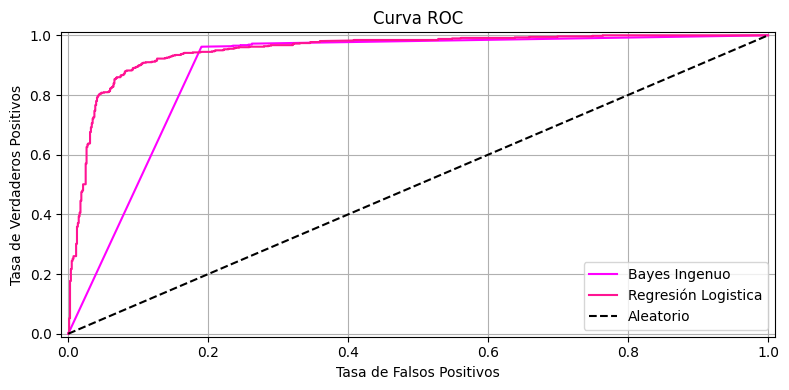

In [96]:
colors = ["#00FFFF", "#FF00FF", "#FF1493", "#00BFFF", "#FF6347"]

plt.figure(figsize=(8, 4))
plt.plot(fpr_y_multinomial, tpr_y_multinomial, label=titles[0], color=colors[1])
plt.plot(fpr_y_regression, tpr_y_regression, label=titles[1], color=colors[2])
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.tight_layout();

Calculo del AUC

In [92]:
from sklearn.metrics import roc_auc_score

print(titles[0])
print(f"AUC: {roc_auc_score(y_test, y_multinomial_proba[:, 1])}\n")

print(titles[1])
print(f"AUC: {roc_auc_score(y_test, y_regression_proba[:, 1])}")


Bayes Ingenuo
AUC: 0.8883463962682256

Regresión Logistica
AUC: 0.9517242642937823
